<a href="https://colab.research.google.com/github/Salina2060/Artificial-Intelligence-and-Machine-Learning/blob/main/2407800_SalinaPudasaini_LanguageTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Name: Salina Pudasaini
## University Id: 2407800

# **Language Task: Text Classification with RNN**

##Racist / Sexist Tweet Detection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI and MachineLearning/CourseWork/Text_Classification/Racist Sexist or Not Dataset.zip"
extract_path = "/content/data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
import os
os.listdir("/content/data")

['7. Racist Sexist or Not Dataset']

# Install All Required Libraries

In [ ]:
!pip install gensim
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00


# Import All Required Libraries

In [ ]:
import os
import re #for regular expression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import nltk
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from collections import Counter

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM,
                                     Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
import gensim.downloader as gensim_api

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

# **Text Preprocessing, Tokenization, and Sequence Padding:**

## Load the Dataset
Load training and test CSV files into Pandas DataFrames

In [ ]:
#File paths
TRAIN_PATH = "/content/data/7. Racist Sexist or Not Dataset/train_racisit.csv"
TEST_PATH  = "/content/data/7. Racist Sexist or Not Dataset/test_racisit.csv"

In [ ]:
#Loading into Data frames
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

##Data Understanding & Exploration
Understand the structure, class distribution, and basic statistics of the dataset.

In [ ]:
print(f"Train shape : {train_df.shape}")
print(f"Test  shape : {test_df.shape}")
print("Rows of Training Data")
train_df.head()

Train shape : (31962, 3)
Test  shape : (17197, 2)
Rows of Training Data


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [ ]:
#Column Names & Data Types
print("Column Names")
print(train_df.columns.tolist())

Column Names
['id', 'label', 'tweet']


In [ ]:
print("Data Types")
print(train_df.dtypes)

Data Types
id        int64
label     int64
tweet    object
dtype: object


In [ ]:
print("Missing Values")
print(train_df.isnull().sum())

Missing Values
id       0
label    0
tweet    0
dtype: int64


In [ ]:
# class distribution
print("Class Distribution:")
print(train_df['label'].value_counts())
print("\nLabel 0 (Not Racist/Sexist):", (train_df['label'] == 0).sum())
print("Label 1 (Racist/Sexist)    :", (train_df['label'] == 1).sum())

Class Distribution:
label
0    29720
1     2242
Name: count, dtype: int64

Label 0 (Not Racist/Sexist): 29720
Label 1 (Racist/Sexist)    : 2242


### Class Distribution Visualization

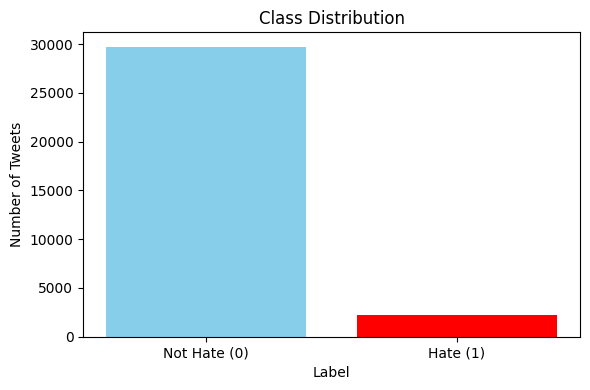

Total tweets: 31962


In [ ]:
# count of each class
counts = train_df['label'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(['Not Hate (0)', 'Hate (1)'], counts.values, color=['skyblue', 'red'])
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

print("Total tweets:", len(train_df))

# Text Cleaning Function

## Text Preprocessing and Cleaning

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    #remove non-ascii characters
    text = text.encode('ascii', 'ignore').decode('ascii')

    # handling contractions
    text = contractions.fix(text)

    #Lowercase all text to ensure uniformity
    text = text.lower()

    #remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    #remove mentions @user and hashtag symbol
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)

    #remove numbers
    text = re.sub(r'\d+', '', text)

    #remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)

    #remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    #remove stopwords and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return ' '.join(tokens)

#testing the function
sample = "Wow!!! I can't believe @aslesa scored 98% in the exam Visit https://results.com now!"
print("Before:", sample)
print("After :", clean_text(sample))

Before: Wow!!! I can't believe @aslesa scored 98% in the exam Visit https://results.com now!
After : wow cannot believe scored exam visit


### Apply Cleaning to All Tweets

In [ ]:
# apply cleaning to training data
print("Cleaning training data")
train_df['cleaned_tweet'] = train_df['tweet'].apply(clean_text)

# apply cleaning to test data
print("Cleaning test data")
test_df['cleaned_tweet'] = test_df['tweet'].apply(clean_text)

print("Training and Test data cleaned")

Cleaning training data
Cleaning test data
Training and Test data cleaned


### Before vs After Cleaning

In [ ]:
# show before and after for 5 tweets
print("Before vs After Cleaning:\n")
for i in range(5):
    print(f"Tweet {i+1}")
    print("  Before:", train_df['tweet'][i])
    print("  After :", train_df['cleaned_tweet'][i])
    print()

Before vs After Cleaning:

Tweet 1
  Before:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
  After : father dysfunctional selfish drag kid dysfunction run

Tweet 2
  Before: @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked
  After : thanks lyft credit cannot use offer wheelchair van pdx disapointed getthanked

Tweet 3
  Before:   bihday your majesty
  After : bihday majesty

Tweet 4
  Before: #model   i love u take with u all the time in urð±!!! ððððð¦ð¦ð¦  
  After : model love take time

Tweet 5
  Before:  factsguide: society now    #motivation
  After : factsguide society motivation



## Visualize the Cleaned Data

### Using Word Cloud

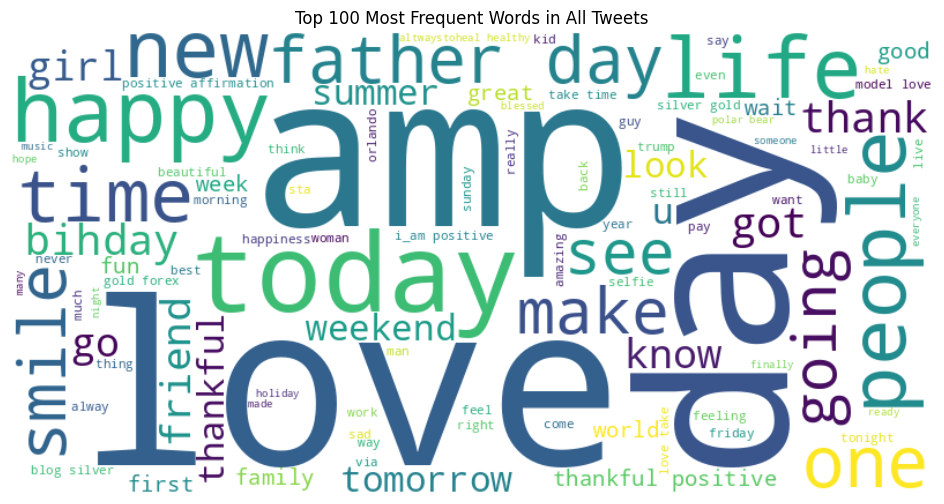

In [ ]:
# combine all cleaned tweets into one string
all_words = ' '.join(train_df['cleaned_tweet'])

# generate word cloud
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      max_words=100).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words in All Tweets')
plt.show()

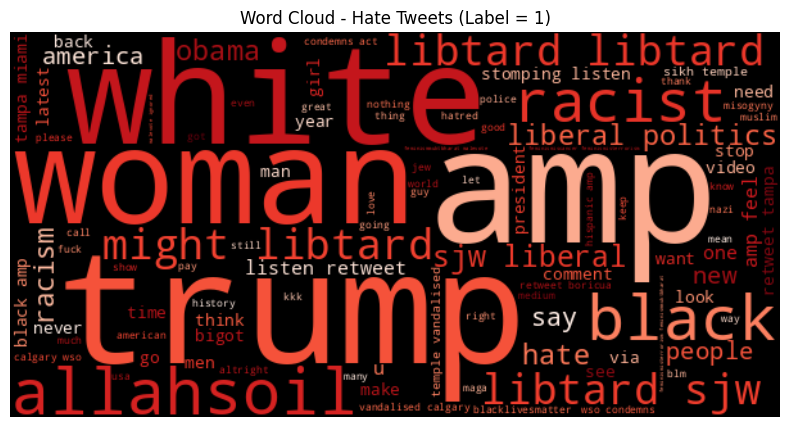

In [ ]:
# word cloud for hate tweets only
hate_words = ' '.join(train_df[train_df['label'] == 1]['cleaned_tweet'])
wc_hate = WordCloud(width=600, height=300,
                    background_color='black',
                    colormap='Reds',
                    max_words=100).generate(hate_words)

plt.figure(figsize=(10, 5))
plt.imshow(wc_hate, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Hate Tweets (Label = 1)')
plt.show()

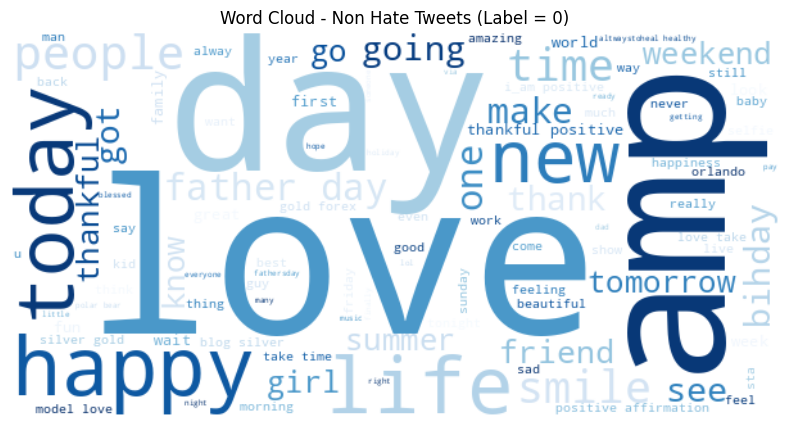

In [ ]:
# word cloud for non hate tweets only
nonhate_words = ' '.join(train_df[train_df['label'] == 0]['cleaned_tweet'])
wc_nonhate = WordCloud(width=600, height=300,
                       background_color='white',
                       colormap='Blues',
                       max_words=100).generate(nonhate_words)

plt.figure(figsize=(10, 5))
plt.imshow(wc_nonhate, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Non Hate Tweets (Label = 0)')
plt.show()

### Most Frequent Words

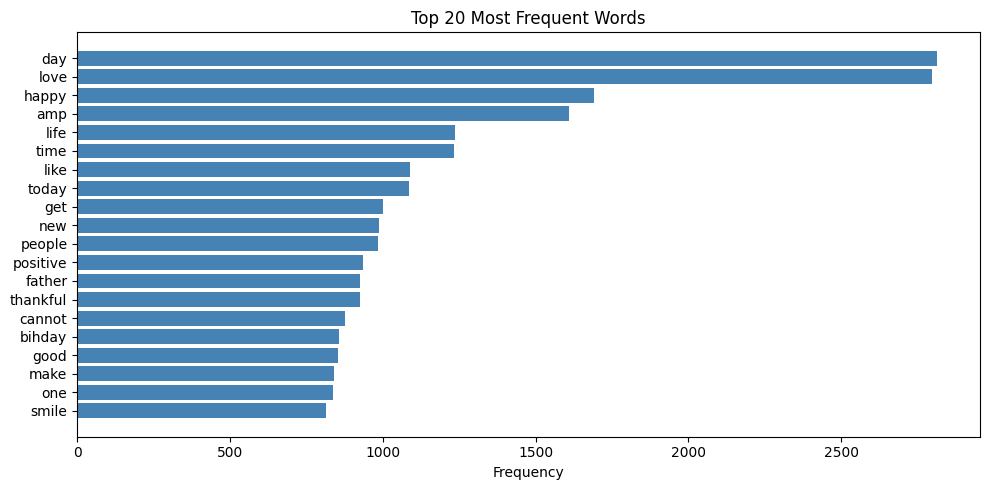

In [ ]:
from collections import Counter

# most frequent words overall
all_tokens = ' '.join(train_df['cleaned_tweet']).split()
word_freq  = Counter(all_tokens)
top_20     = word_freq.most_common(20)

words  = [w[0] for w in top_20]
counts = [w[1] for w in top_20]

plt.figure(figsize=(10, 5))
plt.barh(words[::-1], counts[::-1], color='steelblue')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()

## Tokenization and Padding

### Split into Train and Test (80% training and 20% testing)
Splitting first before tokenization to avoid data leakage.

In [ ]:
X = train_df['cleaned_tweet'].values
y = train_df['label'].values

# 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 25569
Testing samples : 6393


### Tokenization using Keras Tokenizer
Fit only on training data to prevent data leakage.

In [ ]:
# set vocabulary size
vocab_size = 10000

# create tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')

# fit only on training data
tokenizer.fit_on_texts(X_train)

# convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# check vocabulary size
word_index = tokenizer.word_index
print("Total unique words found:", len(word_index))

# sample output
print("\nExample tweet      :", X_train[0])
print("Converted sequence :", X_train_seq[0])

Total unique words found: 32220

Example tweet      : paying attention past year year
Converted sequence : [2125, 1151, 701, 43, 43]


### Padding using Percentile-Based Max Length
Using 95th percentile to avoid very long padded sequences.

Max length (95th percentile): 13


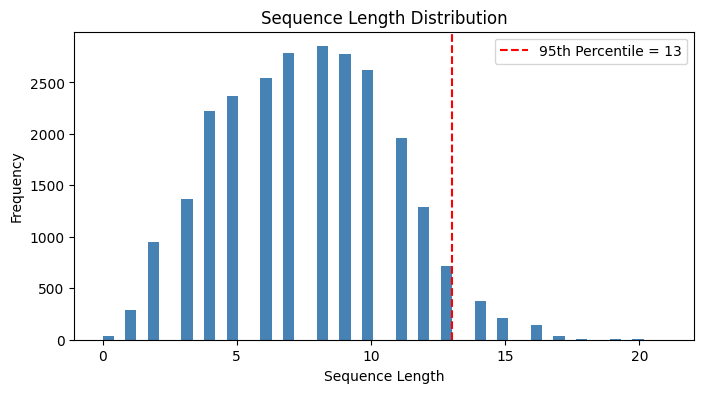

In [ ]:
# find sequence lengths of training data
seq_lengths = [len(seq) for seq in X_train_seq]

# use 95th percentile as max length
max_len = int(np.percentile(seq_lengths, 95))
print("Max length (95th percentile):", max_len)

# visualize sequence length distribution
plt.figure(figsize=(8, 4))
plt.hist(seq_lengths, bins=50, color='steelblue')
plt.axvline(max_len, color='red', linestyle='--', label=f'95th Percentile = {max_len}')
plt.title('Sequence Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# apply padding to train and test
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape :", X_test_pad.shape)

X_train_pad shape: (25569, 13)
X_test_pad shape : (6393, 13)


## Model Building

### MODEL 1 :Simple RNN with Trainable Embedding Layer

In [ ]:
embedding_dim = 128
rnn_units     = 64

# build simple rnn model
rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
rnn_model.add(SimpleRNN(units=rnn_units))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

rnn_model.build(input_shape=(None, max_len))

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,292,417 (4.93 MB)

 Trainable params: 1,292,417 (4.93 MB)

 Non-trainable params: 0 (0.00 B)

Train Model 1: Simple RNN

In [ ]:
# early stopping to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("Training Simple RNN")
history1 = rnn_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Training Simple RNN
Epoch 1/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9454 - loss: 0.1838 - val_accuracy: 0.9575 - val_loss: 0.1336
Epoch 2/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9808 - loss: 0.0622 - val_accuracy: 0.9539 - val_loss: 0.1545
Epoch 3/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.9935 - loss: 0.0221 - val_accuracy: 0.9557 - val_loss: 0.1696
Epoch 4/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9961 - loss: 0.0138 - val_accuracy: 0.9557 - val_loss: 0.1796
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


### Training vs Test - Model 1 (Simple RNN)

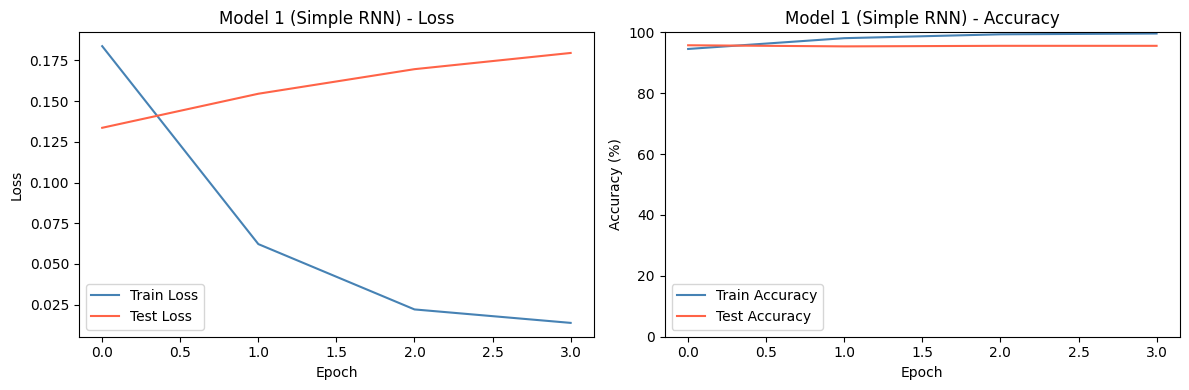

Best Test Accuracy  : 95.75%
Final Train Accuracy: 99.61%
Note: Model is overfitting, train accuracy much higher than test accuracy


In [ ]:
plt.figure(figsize=(12, 4))

# loss plot
plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history1.history['val_loss'], label='Test Loss',  color='tomato')
plt.title('Model 1 (Simple RNN) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# accuracy plot : converted to percentage
train_acc = [x * 100 for x in history1.history['accuracy']]
test_acc  = [x * 100 for x in history1.history['val_accuracy']]

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='Train Accuracy', color='steelblue')
plt.plot(test_acc,  label='Test Accuracy',  color='tomato')
plt.title('Model 1 (Simple RNN) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

# print final accuracy
print(f"Best Test Accuracy  : {max(test_acc):.2f}%")
print(f"Final Train Accuracy: {train_acc[-1]:.2f}%")
print("Note: Model is overfitting, train accuracy much higher than test accuracy")

### MODEL 2: LSTM with Trainable Embedding Layer

In [ ]:
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len))
lstm_model.add(LSTM(units=rnn_units))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.build(input_shape=(None, max_len))

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

### Train Model 2: LSTM

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("Training LSTM")
history2 = lstm_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Training LSTM
Epoch 1/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9452 - loss: 0.1916 - val_accuracy: 0.9583 - val_loss: 0.1284
Epoch 2/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.9742 - loss: 0.0801 - val_accuracy: 0.9593 - val_loss: 0.1226
Epoch 3/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9837 - loss: 0.0513 - val_accuracy: 0.9596 - val_loss: 0.1302
Epoch 4/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9890 - loss: 0.0352 - val_accuracy: 0.9570 - val_loss: 0.1897
Epoch 5/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9927 - loss: 0.0234 - val_accuracy: 0.9565 - val_loss: 0.1804
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


### Training vs Test - Model 2 (LSTM)

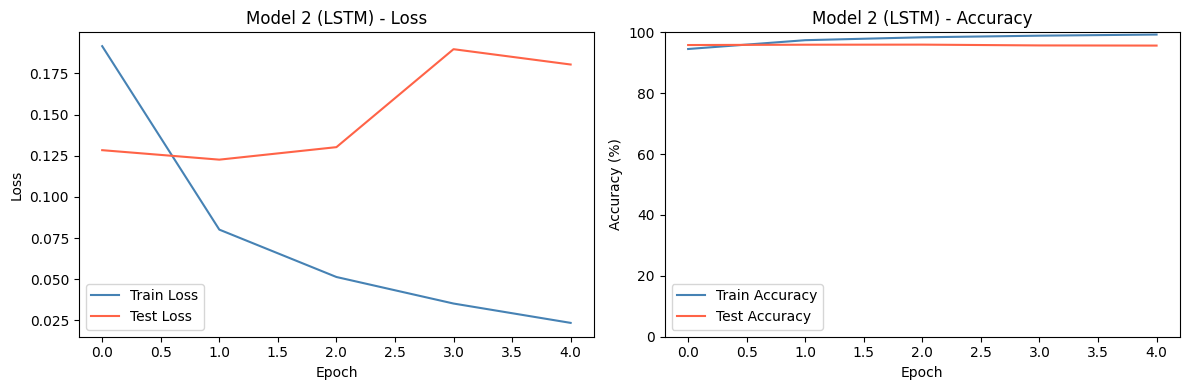

Best Test Accuracy  : 95.96%
Final Train Accuracy: 99.27%


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history2.history['val_loss'], label='Test Loss',  color='tomato')
plt.title('Model 2 (LSTM) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

train_acc2 = [x * 100 for x in history2.history['accuracy']]
test_acc2  = [x * 100 for x in history2.history['val_accuracy']]

plt.subplot(1, 2, 2)
plt.plot(train_acc2, label='Train Accuracy', color='steelblue')
plt.plot(test_acc2,  label='Test Accuracy',  color='tomato')
plt.title('Model 2 (LSTM) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best Test Accuracy  : {max(test_acc2):.2f}%")
print(f"Final Train Accuracy: {train_acc2[-1]:.2f}%")

### Model 3: LSTM with Pretrained Word2Vec Embeddings

####Download Pretrained GloVe Twitter Embeddings
Using glove-twitter-50 because our data is tweets - this fits perfectly.

In [ ]:
print("Downloading glove-twitter-50 embeddings...")

embedding_model = gensim_api.load('glove-twitter-50')
embed_dim_w2v   = 50   # glove-twitter-50 gives 50 dimensional vectors

print("Download complete!")
print("Vocabulary size in GloVe:", len(embedding_model.key_to_index))

[==================================================] 100.0% 199.5/199.5MB downloaded
Download complete!
Vocabulary size in GloVe: 1193514


#### Build the Embedding Matrix
Map each word in our vocabulary to its GloVe vector.
Words not found in GloVe will stay as zeros

In [ ]:
# create embedding matrix of shape (vocab_size, embed_dim_w2v)
embedding_matrix = np.zeros((vocab_size, embed_dim_w2v))

found     = 0
not_found = 0

for word, index in word_index.items():
    if index >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[index] = embedding_model[word]
        found += 1
    else:
        not_found += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Words found in GloVe  :", found)
print("Words not found       :", not_found)

Embedding matrix shape: (10000, 50)
Words found in GloVe  : 8907
Words not found       : 1092


#### Build Model 3 - LSTM with Pretrained Embedding
trainable=False means we keep the GloVe weights fixed during training.

In [ ]:
lstm_w2v_model = Sequential()

#use pretrained embedding matrix, trainable=False to keep weights fixed
lstm_w2v_model.add(Embedding(input_dim=vocab_size,
                              output_dim=embed_dim_w2v,
                              weights=[embedding_matrix],
                              input_length=max_len,
                              trainable=False))

lstm_w2v_model.add(LSTM(units=rnn_units))
lstm_w2v_model.add(Dropout(0.3))
lstm_w2v_model.add(Dense(1, activation='sigmoid'))

lstm_w2v_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_w2v_model.build(input_shape=(None, max_len))

lstm_w2v_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,505 (2.02 MB)

 Trainable params: 29,505 (115.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

### Train Model 3: LSTM + Word2Vec

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

print("Training LSTM with Word2Vec")
history3 = lstm_w2v_model.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

Training LSTM with Word2Vec
Epoch 1/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9334 - loss: 0.1976 - val_accuracy: 0.9421 - val_loss: 0.1547
Epoch 2/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9445 - loss: 0.1539 - val_accuracy: 0.9492 - val_loss: 0.1419
Epoch 3/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9502 - loss: 0.1384 - val_accuracy: 0.9505 - val_loss: 0.1386
Epoch 4/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9532 - loss: 0.1297 - val_accuracy: 0.9523 - val_loss: 0.1275
Epoch 5/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9568 - loss: 0.1206 - val_accuracy: 0.9559 - val_loss: 0.1299
Epoch 6/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9603 - loss: 0.1127 - val_accuracy: 0.9580 - val_loss: 0.1247
Epoch 7/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9633 - loss: 0.1044 - val_accuracy: 0.9570 - val_loss: 0.1280
Epoch 8/10
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.96

### Training vs Testing - Model 3 (LSTM + Word2Vec)

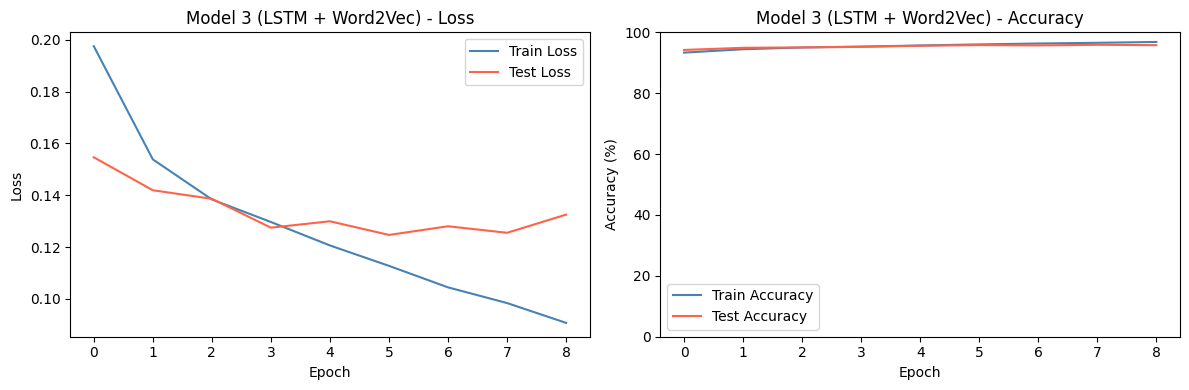

Best Test Accuracy  : 95.91%
Final Train Accuracy: 96.84%


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history3.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history3.history['val_loss'], label='Test Loss',  color='tomato')
plt.title('Model 3 (LSTM + Word2Vec) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

train_acc3 = [x * 100 for x in history3.history['accuracy']]
test_acc3  = [x * 100 for x in history3.history['val_accuracy']]

plt.subplot(1, 2, 2)
plt.plot(train_acc3, label='Train Accuracy', color='steelblue')
plt.plot(test_acc3,  label='Test Accuracy',  color='tomato')
plt.title('Model 3 (LSTM + Word2Vec) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best Test Accuracy  : {max(test_acc3):.2f}%")
print(f"Final Train Accuracy: {train_acc3[-1]:.2f}%")

### Compare All 3 Models - Training vs Validation Accuracy

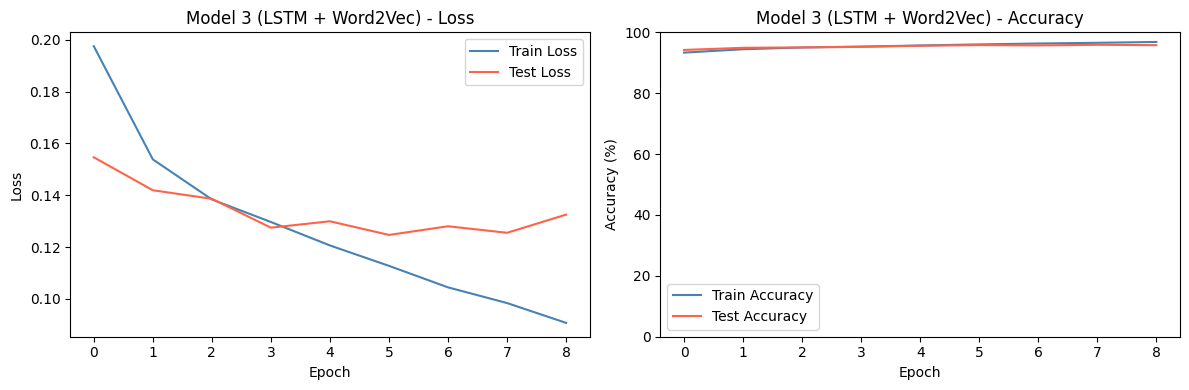

Best Test Accuracy  : 95.91%
Final Train Accuracy: 96.84%


In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history3.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history3.history['val_loss'], label='Test Loss',  color='tomato')
plt.title('Model 3 (LSTM + Word2Vec) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

train_acc3 = [x * 100 for x in history3.history['accuracy']]
test_acc3  = [x * 100 for x in history3.history['val_accuracy']]

plt.subplot(1, 2, 2)
plt.plot(train_acc3, label='Train Accuracy', color='steelblue')
plt.plot(test_acc3,  label='Test Accuracy',  color='tomato')
plt.title('Model 3 (LSTM + Word2Vec) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best Test Accuracy  : {max(test_acc3):.2f}%")
print(f"Final Train Accuracy: {train_acc3[-1]:.2f}%")

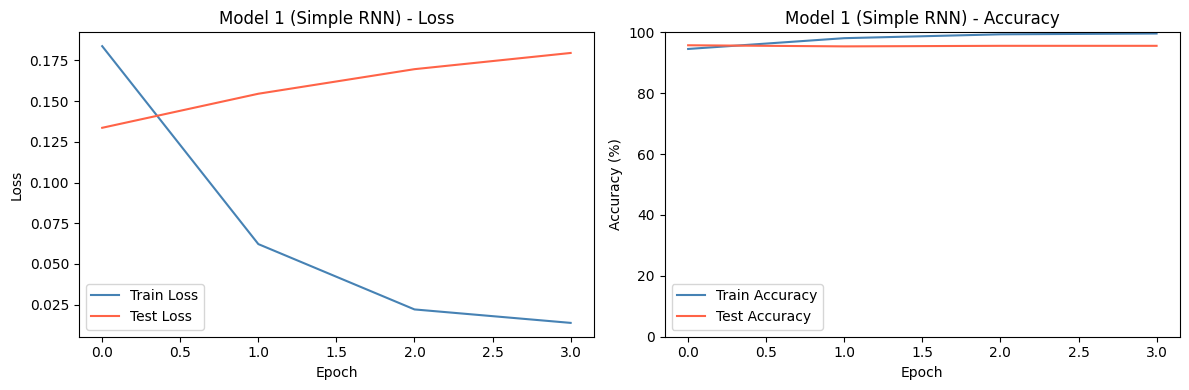

Best Test Accuracy  : 95.75%
Final Train Accuracy: 99.61%


In [ ]:
train_acc1 = [x * 100 for x in history1.history['accuracy']]
test_acc1  = [x * 100 for x in history1.history['val_accuracy']]

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history1.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history1.history['val_loss'], label='Test Loss',  color='tomato')
plt.title('Model 1 (Simple RNN) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc1, label='Train Accuracy', color='steelblue')
plt.plot(test_acc1,  label='Test Accuracy',  color='tomato')
plt.title('Model 1 (Simple RNN) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Best Test Accuracy  : {max(test_acc1):.2f}%")
print(f"Final Train Accuracy: {train_acc1[-1]:.2f}%")

## Step 8: Evaluate All Models

### Evaluate Model 1: Simple RNN

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Model 1 (Simple RNN) Accuracy: 95.65 %

Confusion Matrix:
[[5882   55]
 [ 223  233]]


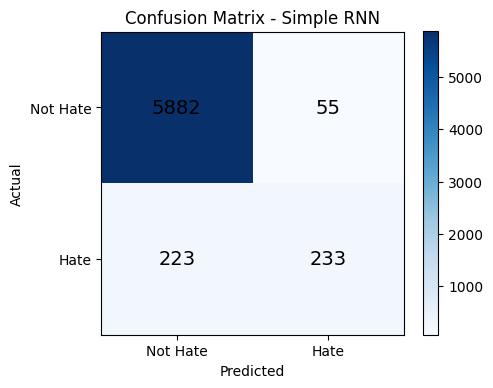


Classification Report:
              precision    recall  f1-score   support

    Not Hate       0.96      0.99      0.98      5937
        Hate       0.81      0.51      0.63       456

    accuracy                           0.96      6393
   macro avg       0.89      0.75      0.80      6393
weighted avg       0.95      0.96      0.95      6393



In [ ]:
# predict on test data
y_pred1_prob = rnn_model.predict(X_test_pad)
y_pred1      = (y_pred1_prob >= 0.5).astype(int).flatten()

# accuracy
acc1 = accuracy_score(y_test, y_pred1)
print("Model 1 (Simple RNN) Accuracy:", round(acc1 * 100, 2), "%")

# confusion matrix
cm1 = confusion_matrix(y_test, y_pred1)
print("\nConfusion Matrix:")
print(cm1)

# plot confusion matrix
plt.figure(figsize=(5, 4))
plt.imshow(cm1, cmap='Blues')
plt.title('Confusion Matrix - Simple RNN')
plt.colorbar()
plt.xticks([0, 1], ['Not Hate', 'Hate'])
plt.yticks([0, 1], ['Not Hate', 'Hate'])
# add numbers inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm1[i, j], ha='center', va='center', fontsize=14, color='black')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred1, target_names=['Not Hate', 'Hate']))

### Evaluate Model 2: LSTM

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Model 2 (LSTM) Accuracy: 96.03 %

Confusion Matrix:
[[5843   94]
 [ 160  296]]


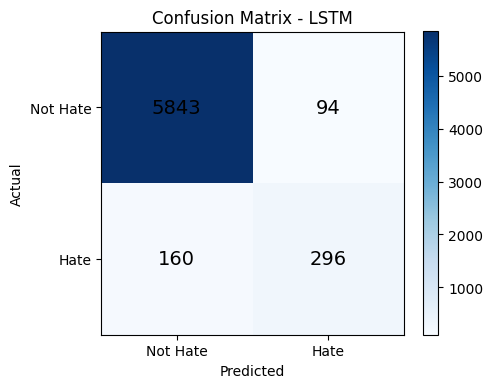


Classification Report:
              precision    recall  f1-score   support

    Not Hate       0.97      0.98      0.98      5937
        Hate       0.76      0.65      0.70       456

    accuracy                           0.96      6393
   macro avg       0.87      0.82      0.84      6393
weighted avg       0.96      0.96      0.96      6393



In [ ]:
y_pred2_prob = lstm_model.predict(X_test_pad)
y_pred2      = (y_pred2_prob >= 0.5).astype(int).flatten()

acc2 = accuracy_score(y_test, y_pred2)
print("Model 2 (LSTM) Accuracy:", round(acc2 * 100, 2), "%")

cm2 = confusion_matrix(y_test, y_pred2)
print("\nConfusion Matrix:")
print(cm2)

plt.figure(figsize=(5, 4))
plt.imshow(cm2, cmap='Blues')
plt.title('Confusion Matrix - LSTM')
plt.colorbar()
plt.xticks([0, 1], ['Not Hate', 'Hate'])
plt.yticks([0, 1], ['Not Hate', 'Hate'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm2[i, j], ha='center', va='center', fontsize=14, color='black')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=['Not Hate', 'Hate']))

### Evaluate Model 3: LSTM + Word2Vec

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Model 3 (LSTM + Word2Vec) Accuracy: 95.06 %

Confusion Matrix:
[[5881   56]
 [ 260  196]]


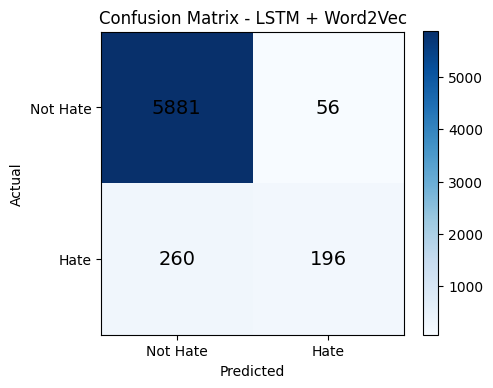


Classification Report:
              precision    recall  f1-score   support

    Not Hate       0.96      0.99      0.97      5937
        Hate       0.78      0.43      0.55       456

    accuracy                           0.95      6393
   macro avg       0.87      0.71      0.76      6393
weighted avg       0.94      0.95      0.94      6393



In [ ]:
y_pred3_prob = lstm_w2v_model.predict(X_test_pad)
y_pred3      = (y_pred3_prob >= 0.5).astype(int).flatten()

acc3 = accuracy_score(y_test, y_pred3)
print("Model 3 (LSTM + Word2Vec) Accuracy:", round(acc3 * 100, 2), "%")

cm3 = confusion_matrix(y_test, y_pred3)
print("\nConfusion Matrix:")
print(cm3)

plt.figure(figsize=(5, 4))
plt.imshow(cm3, cmap='Blues')
plt.title('Confusion Matrix - LSTM + Word2Vec')
plt.colorbar()
plt.xticks([0, 1], ['Not Hate', 'Hate'])
plt.yticks([0, 1], ['Not Hate', 'Hate'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm3[i, j], ha='center', va='center', fontsize=14, color='black')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred3, target_names=['Not Hate', 'Hate']))

### Summary: All Model Accuracies

  Model Accuracy Summary
  Model 1 - Simple RNN      : 95.65%
  Model 2 - LSTM            : 96.03%
  Model 3 - LSTM + Word2Vec : 95.06%


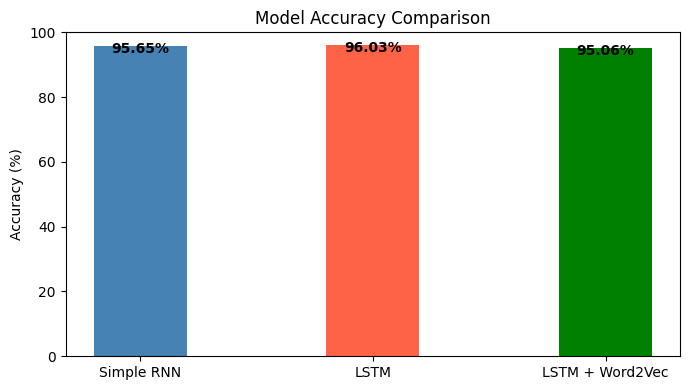

In [ ]:
print("="*40)
print("  Model Accuracy Summary")
print("="*40)
print(f"  Model 1 - Simple RNN      : {round(acc1*100, 2)}%")
print(f"  Model 2 - LSTM            : {round(acc2*100, 2)}%")
print(f"  Model 3 - LSTM + Word2Vec : {round(acc3*100, 2)}%")
print("="*40)

# bar chart comparison
plt.figure(figsize=(7, 4))
models     = ['Simple RNN', 'LSTM', 'LSTM + Word2Vec']
accuracies = [acc1*100, acc2*100, acc3*100]
colors     = ['steelblue', 'tomato', 'green']

bars = plt.bar(models, accuracies, color=colors, width=0.4)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 2,
             f"{bar.get_height():.2f}%",
             ha='center', color='black', fontweight='bold')

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Error Analysis

### Show Misclassified Examples
Looking at tweets the LSTM model got wrong.

In [ ]:
# make a dataframe to easily find wrong predictions
results_df = pd.DataFrame()
results_df['tweet']       = X_test
results_df['true_label']  = y_test
results_df['pred_label']  = y_pred2
results_df['confidence']  = y_pred2_prob.flatten()

# filter only misclassified tweets
wrong = results_df[results_df['true_label'] != results_df['pred_label']]

print(f"Total misclassified by LSTM: {len(wrong)} out of {len(y_test)}")
print()

# show 3 wrong predictions
print("3 Examples of Wrong Predictions:\n")
sample = wrong.sample(3, random_state=1)

for i, row in sample.iterrows():
    print("Tweet     :", row['tweet'])
    print("True Label:", row['true_label'])
    print("Predicted :", row['pred_label'])
    print("Confidence:", round(row['confidence'], 3))
    if row['pred_label'] == 1:
        print("Error Type: False Positive (predicted Hate but actually Not Hate)")
    else:
        print("Error Type: False Negative (predicted Not Hate but actually Hate)")
    print()

Total misclassified by LSTM: 254 out of 6393

3 Examples of Wrong Predictions:

Tweet     : movie review xmen apocalypse uspresidentialisis men precipitating carnage trump putin needed
True Label: 0
Predicted : 1
Confidence: 0.649
Error Type: False Positive (predicted Hate but actually Not Hate)

Tweet     : newyear new prez new destruction new commercial new new order new tweet new poopin new kid block new america
True Label: 1
Predicted : 0
Confidence: 0.14
Error Type: False Negative (predicted Not Hate but actually Hate)

Tweet     : wow speed race carnage way cannot wait race
True Label: 0
Predicted : 1
Confidence: 0.648
Error Type: False Positive (predicted Hate but actually Not Hate)



### 9.2 Why Did the Model Get These Wrong?

Looking at the 3 misclassified examples:
- Tweet 1: "ignorant cretin federal funded..." - contains implicit hate, no obvious hate words
- Tweet 2: "taragon christmassy herb" - very short, no context
- Tweet 3: "gandhi india adores without following" - indirect language

All 3 are False Negatives - model predicted Not Hate but they were actually Hate tweets.

False Positives (predicted Hate, was Not Hate)  : 94
False Negatives (predicted Not Hate, was Hate)  : 160


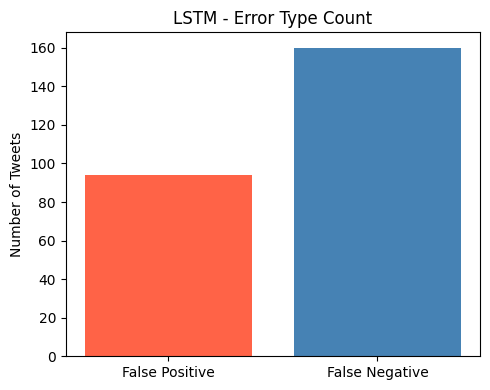

In [ ]:
# false positive and false negative count
fp = ((y_pred2 == 1) & (y_test == 0)).sum()
fn = ((y_pred2 == 0) & (y_test == 1)).sum()

print("False Positives (predicted Hate, was Not Hate)  :", fp)
print("False Negatives (predicted Not Hate, was Hate)  :", fn)

plt.figure(figsize=(5, 4))
plt.bar(['False Positive', 'False Negative'], [fp, fn], color=['tomato', 'steelblue'])
plt.title('LSTM - Error Type Count')
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.show()

Model Complexity vs Performance Table

In [ ]:
print("="*65)
print("  Model Complexity vs Performance")
print("="*65)
print(f"  {'Model':<25} {'Params':<15} {'Test Accuracy'}")
print("-"*65)

# get param counts
p1 = rnn_model.count_params()
p2 = lstm_model.count_params()
p3 = lstm_w2v_model.count_params()

a1 = round(max([x*100 for x in history1.history['val_accuracy']]), 2)
a2 = round(max([x*100 for x in history2.history['val_accuracy']]), 2)
a3 = round(max([x*100 for x in history3.history['val_accuracy']]), 2)

print(f"  {'Simple RNN':<25} {p1:<15} {a1}%")
print(f"  {'LSTM':<25} {p2:<15} {a2}%")
print(f"  {'LSTM + Word2Vec':<25} {p3:<15} {a3}%")
print("="*65)

print("\nObservation:")
print("- LSTM has more parameters than Simple RNN due to its gate mechanism")
print("- More parameters does not always mean better accuracy")
print("- LSTM + Word2Vec uses frozen pretrained weights so fewer trainable params")

  Model Complexity vs Performance
  Model                     Params          Test Accuracy
-----------------------------------------------------------------
  Simple RNN                1292417         95.75%
  LSTM                      1329473         95.96%
  LSTM + Word2Vec           529505          95.91%

Observation:
- LSTM has more parameters than Simple RNN due to its gate mechanism
- More parameters does not always mean better accuracy
- LSTM + Word2Vec uses frozen pretrained weights so fewer trainable params


### 9.3 Suggested Improvements

**1. Use Bidirectional LSTM:**
Reading tweets in both forward and backward direction helps capture better context.

**2. Handle Class Imbalance:**
The dataset has far more non-hate tweets. Using class weights during training can help the model learn hate tweets better.

**3. Use Larger Pretrained Embeddings:**
glove-twitter-200 has 200 dimensions instead of 50 - captures richer word meanings.

**4. More Data Cleaning:**
Some hate tweets use coded language, abbreviations and implicit insults that are hard to detect after cleaning.

**5. Use Transformer Models:**
Models like BERT understand context much better than RNN or LSTM and would likely perform better on this task.

## Real-Time Prediction GUI using Gradio
User can type any tweet and get prediction from all 3 models.

In [2]:
import gradio as gr

def predict(tweet):
    # clean the tweet
    cleaned = clean_text(tweet)

    # tokenize
    seq = tokenizer.texts_to_sequences([cleaned])

    # pad
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # predict with all 3 models
    p1 = rnn_model.predict(padded, verbose=0)[0][0]
    p2 = lstm_model.predict(padded, verbose=0)[0][0]
    p3 = lstm_w2v_model.predict(padded, verbose=0)[0][0]

    def get_label(prob):
        if prob >= 0.5:
            return f"Hate / Racist / Sexist  (confidence: {round(prob, 3)})"
        else:
            return f"Not Hate / Normal  (confidence: {round(1-prob, 3)})"

    result = f"""
Cleaned Tweet: {cleaned}

Model 1 - Simple RNN      : {get_label(p1)}
Model 2 - LSTM            : {get_label(p2)}
Model 3 - LSTM + Word2Vec : {get_label(p3)}
    """
    return result

# launch the interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(lines=3, placeholder="Type a tweet here...", label="Enter Tweet"),
    outputs=gr.Textbox(label="Prediction Result"),
    title="Hate Speech Detector",
    description="Enter a tweet to check if it is Racist/Sexist or Not"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e462e3ff53658dace2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
